### Here we train a federared time-series model with exogenous data. Our exogenous data are the datetime features and statistics describing the previous time steps such as mean and median for the targets of interest, i.e., up and down measurements.


在此，我们训练一个结合外生数据（exogenous data）的联邦时序模型。我们的外生数据包括日期时间特征以及描述前序时间步统计信息的指标（如目标变量——即上、下游测量值的均值和分位数等统计特征）。

In [29]:
import sys
import os

from pathlib import Path

parent = Path(os.path.abspath("")).resolve().parents[0]
if parent not in sys.path:
    sys.path.insert(0, str(parent))

In [30]:
import copy

import random

from collections import OrderedDict

import numpy as np
import torch

import pandas as pd

from matplotlib import pyplot as plt

from argparse import Namespace

In [31]:
from ml.utils.data_utils import read_data, generate_time_lags, time_to_feature, handle_nans, to_Xy, \
    to_torch_dataset, to_timeseries_rep, assign_statistics, \
    to_train_val, scale_features, get_data_by_area, remove_identifiers, get_exogenous_data_by_area, handle_outliers

In [32]:
from ml.utils.train_utils import train, test

In [33]:
from ml.models.mlp import MLP
from ml.models.rnn import RNN
from ml.models.lstm import LSTM
from ml.models.gru import GRU
from ml.models.cnn import CNN
from ml.models.rnn_autoencoder import DualAttentionAutoEncoder

In [34]:
from ml.fl.defaults import create_regression_client
from ml.fl.client_proxy import SimpleClientProxy
from ml.fl.server.server import Server
from ml.utils.helpers import accumulate_metric

In [35]:
args = Namespace(
    data_path='../CBL-dataset/LCL-June2015v2_0.csv', # 电力数据集路径

    test_size=0.2, # validation size 
    targets=['kwh'], # 目标列：用电量
    num_lags=10, # the number of past observations to feed as input

    identifier='customer_id', # 标识客户的列名

    nan_constant=0, # the constant to transform nan values
    x_scaler='minmax', # x_scaler
    y_scaler='minmax', # y_scaler
    outlier_detection=None, # whether to perform flooring and capping

    criterion='mse', # optimization criterion, mse or l1
    fl_rounds=3, # the number of federated rounds
    fraction=1., # the percentage of available client to consider for random selection
    aggregation="fedavg", # federated aggregation algorithm
    epochs=3, # the number of maximum local epochs
    lr=0.001, # learning rate
    optimizer='adam', # the optimizer, it can be sgd or adam
    batch_size=128, # the batch size to use
    local_early_stopping=False, # whether to use early stopping
    local_patience=50, # patience value for the early stopping parameter (if specified)
    max_grad_norm=0.0, # whether to clip grad norm
    reg1=0.0, # l1 regularization
    reg2=0.0, # l2 regularization

    cuda=True, # whether to use gpu
    
    seed=0, # reproducibility

    # here we define the exogenous data
    assign_stats=["mean", "median", "std", "variance", "kurtosis", "skew"],
    use_time_features=True # whether to use datetime features
)

In [36]:
print(f"Script arguments: {args}\n")

Script arguments: Namespace(data_path='../CBL-dataset/LCL-June2015v2_0.csv', test_size=0.2, targets=['kwh'], num_lags=10, identifier='customer_id', nan_constant=0, x_scaler='minmax', y_scaler='minmax', outlier_detection=None, criterion='mse', fl_rounds=3, fraction=1.0, aggregation='fedavg', epochs=3, lr=0.001, optimizer='adam', batch_size=128, local_early_stopping=False, local_patience=50, max_grad_norm=0.0, reg1=0.0, reg2=0.0, cuda=True, seed=0, assign_stats=['mean', 'median', 'std', 'variance', 'kurtosis', 'skew'], use_time_features=True)



In [37]:
device = "cuda" if args.cuda and torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [38]:
# 异常值检测配置（如果需要）
if args.outlier_detection is not None:
    outlier_columns = ['kwh']  # 电力数据只有kwh列
    # 可以根据不同客户设置不同的异常值处理参数
    # 这里使用统一的参数，也可以为每个客户单独设置
    outlier_kwargs = {}  # 如果需要对特定客户设置，可以添加如 {"MAC000002": (10, 90)}
    args.outlier_columns = outlier_columns
    args.outlier_kwargs = outlier_kwargs

In [39]:
def seed_all():
    # ensure reproducibility
    random.seed(args.seed)
    np.random.seed(args.seed)
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [40]:
seed_all()

In [41]:
def make_preprocessing():
    """预处理电力数据集"""
    # 读取数据（使用自定义函数加载电力数据）
    # 加载电力数据集
    df = pd.read_csv(args.data_path)
    
    # 清理列名
    df.columns = df.columns.str.strip()
    
    # 重命名列
    df = df.rename(columns={
        'LCLid': 'customer_id',
        'stdorToU': 'tariff_type',
        'DateTime': 'datetime',
        'KWH/hh (per half hour)': 'kwh'
    })
    
    # 转换数据类型
    df['datetime'] = pd.to_datetime(df['datetime'], format="%Y-%m-%d %H:%M:%S.%f", errors='coerce')
    df['kwh'] = pd.to_numeric(df['kwh'], errors='coerce')
    
    # 删除tariff_type列（字符串类型，不适合建模）
    df = df.drop(['tariff_type'], axis=1)
    
    # 设置时间索引
    df.set_index(pd.DatetimeIndex(df["datetime"]), inplace=True)
    df.drop(["datetime"], axis=1, inplace=True)
    
    # 只保留customer_id和kwh列
    df = df[['customer_id', 'kwh']].copy()
    df['kwh'] = df['kwh'].astype("float32")
    
    # 处理缺失值
    df = handle_nans(train_data=df, constant=args.nan_constant,
                     identifier=args.identifier)
    
    # 分割训练/验证集（传递正确的identifier参数）
    train_data, val_data = to_train_val(df, train_size=1-args.test_size, identifier=args.identifier)
    
    # 处理异常值（如果指定）
    if args.outlier_detection is not None:
        train_data = handle_outliers(df=train_data, columns=args.outlier_columns,
                                     identifier=args.identifier, kwargs=args.outlier_kwargs)
    
    # 获取X和y（传递正确的identifier参数）
    X_train, X_val, y_train, y_val = to_Xy(train_data=train_data, val_data=val_data,
                                          targets=args.targets, identifier=args.identifier)
    
    # 缩放X
    X_train, X_val, x_scalers = scale_features(train_data=X_train, val_data=X_val,
                                              scaler=args.x_scaler,
                                              per_area=True, # the features are scaled locally
                                              identifier=args.identifier)
    # 缩放y
    y_train, y_val, y_scalers = scale_features(train_data=y_train, val_data=y_val,
                                              scaler=args.y_scaler, 
                                              per_area=True,
                                              identifier=args.identifier)
    
    # 生成时间滞后特征
    X_train = generate_time_lags(X_train, args.num_lags, identifier=args.identifier)
    X_val = generate_time_lags(X_val, args.num_lags, identifier=args.identifier)
    y_train = generate_time_lags(y_train, args.num_lags, identifier=args.identifier, is_y=True)
    y_val = generate_time_lags(y_val, args.num_lags, identifier=args.identifier, is_y=True)
    
    # 获取日期时间特征作为外生数据
    date_time_df_train = time_to_feature(
        X_train, args.use_time_features, identifier=args.identifier
    )
    date_time_df_val = time_to_feature(
        X_val, args.use_time_features, identifier=args.identifier
    )
    
    # 获取统计量作为外生数据
    stats_df_train = assign_statistics(X_train, args.assign_stats, args.num_lags,
                                       targets=args.targets, identifier=args.identifier)
    stats_df_val = assign_statistics(X_val, args.assign_stats, args.num_lags, 
                                       targets=args.targets, identifier=args.identifier)
    
    # 合并外生特征（如果有）
    if date_time_df_train is not None or stats_df_train is not None:
        exogenous_data_train = pd.concat([date_time_df_train, stats_df_train], axis=1)
        # 移除重复列（如果有）
        exogenous_data_train = exogenous_data_train.loc[:, ~exogenous_data_train.columns.duplicated()].copy()
        assert len(exogenous_data_train) == len(X_train) == len(y_train)
    else:
        exogenous_data_train = None
    if date_time_df_val is not None or stats_df_val is not None:
        exogenous_data_val = pd.concat([date_time_df_val, stats_df_val], axis=1)
        exogenous_data_val = exogenous_data_val.loc[:, ~exogenous_data_val.columns.duplicated()].copy()
        assert len(exogenous_data_val) == len(X_val) == len(y_val)
    else:
        exogenous_data_val = None
        
    return X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scalers, y_scalers

In [42]:
X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scalers, y_scalers = make_preprocessing()

INFO logger 2026-01-07 16:41:53,191 | data_utils.py:383 | Observations info in MAC000002
INFO logger 2026-01-07 16:41:53,192 | data_utils.py:384 | 	Total number of samples:  24158
INFO logger 2026-01-07 16:41:53,193 | data_utils.py:385 | 	Number of samples for training: 19327
INFO logger 2026-01-07 16:41:53,193 | data_utils.py:386 | 	Number of samples for validation:  4831
INFO logger 2026-01-07 16:41:53,263 | data_utils.py:383 | Observations info in MAC000003
INFO logger 2026-01-07 16:41:53,264 | data_utils.py:384 | 	Total number of samples:  35469
INFO logger 2026-01-07 16:41:53,264 | data_utils.py:385 | 	Number of samples for training: 28376
INFO logger 2026-01-07 16:41:53,265 | data_utils.py:386 | 	Number of samples for validation:  7093
INFO logger 2026-01-07 16:41:53,332 | data_utils.py:383 | Observations info in MAC000004
INFO logger 2026-01-07 16:41:53,333 | data_utils.py:384 | 	Total number of samples:  31677
INFO logger 2026-01-07 16:41:53,334 | data_utils.py:385 | 	Number of

In [43]:
def make_postprocessing(X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scalers, y_scalers):
    """Make data ready to be fed into ml algorithms"""
    # if there are more than one specified areas, get the data per area
    if X_train[args.identifier].nunique() != 1:
        area_X_train, area_X_val, area_y_train, area_y_val = get_data_by_area(X_train, X_val,
                                                                              y_train, y_val, 
                                                                              identifier=args.identifier)
    else:
        area_X_train, area_X_val, area_y_train, area_y_val = None, None, None, None

    # Get the exogenous data per area.
    if exogenous_data_train is not None:
        exogenous_data_train, exogenous_data_val = get_exogenous_data_by_area(exogenous_data_train,
                                                                              exogenous_data_val,
                                                                              identifier=args.identifier)
    # transform to np
    if area_X_train is not None:
        for area in area_X_train:
            tmp_X_train, tmp_y_train, tmp_X_val, tmp_y_val = remove_identifiers(
                area_X_train[area], area_y_train[area], area_X_val[area], area_y_val[area],
                identifier=args.identifier)
            tmp_X_train, tmp_y_train = tmp_X_train.to_numpy(), tmp_y_train.to_numpy()
            tmp_X_val, tmp_y_val = tmp_X_val.to_numpy(), tmp_y_val.to_numpy()
            area_X_train[area] = tmp_X_train
            area_X_val[area] = tmp_X_val
            area_y_train[area] = tmp_y_train
            area_y_val[area] = tmp_y_val
    
    if exogenous_data_train is not None:
        for area in exogenous_data_train:
            exogenous_data_train[area] = exogenous_data_train[area].to_numpy()
            exogenous_data_val[area] = exogenous_data_val[area].to_numpy()
    
    # remove identifiers from features, targets
    X_train, y_train, X_val, y_val = remove_identifiers(X_train, y_train, X_val, y_val,
                                                         identifier=args.identifier)
    assert len(X_train.columns) == len(X_val.columns)
    
    num_features = len(X_train.columns) // args.num_lags
    
    # to timeseries representation
    X_train = to_timeseries_rep(X_train.to_numpy(), num_lags=args.num_lags,
                                            num_features=num_features)
    X_val = to_timeseries_rep(X_val.to_numpy(), num_lags=args.num_lags,
                                          num_features=num_features)
    
    if area_X_train is not None:
        area_X_train = to_timeseries_rep(area_X_train, num_lags=args.num_lags,
                                                     num_features=num_features)
        area_X_val = to_timeseries_rep(area_X_val, num_lags=args.num_lags,
                                                   num_features=num_features)
    
    # transform targets to numpy
    y_train, y_val = y_train.to_numpy(), y_val.to_numpy()
    
    if exogenous_data_train is not None:
        exogenous_data_train_combined, exogenous_data_val_combined = [], []
        for area in exogenous_data_train:
            exogenous_data_train_combined.extend(exogenous_data_train[area])
            exogenous_data_val_combined.extend(exogenous_data_val[area])
        exogenous_data_train_combined = np.stack(exogenous_data_train_combined)
        exogenous_data_val_combined = np.stack(exogenous_data_val_combined)
        exogenous_data_train["all"] = exogenous_data_train_combined
        exogenous_data_val["all"] = exogenous_data_val_combined
    return X_train, X_val, y_train, y_val, area_X_train, area_X_val, area_y_train, area_y_val, exogenous_data_train, exogenous_data_val

In [44]:
X_train, X_val, y_train, y_val, client_X_train, client_X_val, client_y_train, client_y_val, exogenous_data_train, exogenous_data_val = make_postprocessing(X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scalers, y_scalers)

In [45]:
exogenous_data_train.keys()

dict_keys(['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012', 'MAC000013', 'MAC000016', 'MAC000018', 'MAC000019', 'MAC000020', 'MAC000021', 'MAC000022', 'MAC000023', 'MAC000024', 'MAC000025', 'MAC000026', 'MAC000027', 'MAC000028', 'MAC000029', 'MAC000030', 'MAC000032', 'MAC000033', 'MAC000034', 'MAC000035', 'MAC000036', 'all'])

In [46]:
# 查看第一个客户的外生数据（示例）
if exogenous_data_train is not None and len(exogenous_data_train) > 0:
    first_client = next(iter([k for k in exogenous_data_train.keys() if k != "all"]))
    print(f"客户 {first_client} 的外生数据示例（前5行）:")
    print(exogenous_data_train[first_client][:5])
else:
    print("没有外生数据")

客户 MAC000002 的外生数据示例（前5行）:
[[ 9.65925826e-01  2.58819045e-01  1.22464680e-16 -1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  6.12323400e-17  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  6.12323400e-17  1.22464680e-16 -1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 9.65925826e-01 -2.58819045e-01  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 9.65925826e-01 -2.58819045e-01  1.22464680e-16 -1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


In [47]:
# 4 datetime features + 1 (target) * 6 (stats) = 4 + 6 = 10 
# 注意：这里使用第一个客户来检查维度，实际客户ID可能是MAC000002等
if exogenous_data_train is not None and len(exogenous_data_train) > 0:
    first_client = next(iter(exogenous_data_train.keys()))
    print(f"外生特征维度（客户 {first_client}）: {len(exogenous_data_train[first_client][0])}")

外生特征维度（客户 MAC000002）: 10


In [48]:
def get_input_dims(X_train, exogenous_data_train):
    if args.model_name == "mlp":
        input_dim = X_train.shape[1] * X_train.shape[2]
    else:
        input_dim = X_train.shape[2]
    
    if exogenous_data_train is not None:
        if len(exogenous_data_train) == 1:
            cid = next(iter(exogenous_data_train.keys()))
            exogenous_dim = exogenous_data_train[cid].shape[1]
        else:
            exogenous_dim = exogenous_data_train["all"].shape[1]
    else:
        exogenous_dim = 0
    
    return input_dim, exogenous_dim

In [49]:
def get_model(model: str,
              input_dim: int,
              out_dim: int,
              lags: int = 10,
              exogenous_dim: int = 0,
              seed=0):
    if model == "mlp":
        model = MLP(input_dim=input_dim, layer_units=[256, 128, 64], num_outputs=out_dim)
    elif model == "rnn":
        model = RNN(input_dim=input_dim, rnn_hidden_size=128, num_rnn_layers=1, rnn_dropout=0.0,
                    layer_units=[128], num_outputs=out_dim, matrix_rep=True, exogenous_dim=exogenous_dim)
    elif model == "lstm":
        model = LSTM(input_dim=input_dim, lstm_hidden_size=128, num_lstm_layers=1, lstm_dropout=0.0,
                     layer_units=[128], num_outputs=out_dim, matrix_rep=True, exogenous_dim=exogenous_dim)
    elif model == "gru":
        model = GRU(input_dim=input_dim, gru_hidden_size=128, num_gru_layers=1, gru_dropout=0.0,
                    layer_units=[128], num_outputs=out_dim, matrix_rep=True, exogenous_dim=exogenous_dim)
    elif model == "cnn":
        model = CNN(num_features=input_dim, lags=lags, exogenous_dim=exogenous_dim, out_dim=out_dim)
    elif model == "da_encoder_decoder":
        model = DualAttentionAutoEncoder(input_dim=input_dim, architecture="lstm", matrix_rep=True)
    else:
        raise NotImplementedError("Specified model is not implemented. Plese define your own model or choose one from ['mlp', 'rnn', 'lstm', 'gru', 'cnn', 'da_encoder_decoder']")
    return model

In [50]:
# define the model
args.model_name = "rnn"

input_dim, exogenous_dim = get_input_dims(X_train, exogenous_data_train)

print(input_dim, exogenous_dim)

model = get_model(model=args.model_name,
                  input_dim=input_dim,
                  out_dim=y_train.shape[1],
                  lags=args.num_lags,
                  exogenous_dim=exogenous_dim,
                  seed=args.seed)

1 10


In [51]:
model

RNN(
  (rnn): RNN(1, 128, batch_first=True)
  (MLP_layers): Sequential(
    (0): Linear(in_features=138, out_features=1, bias=True)
  )
)

In [52]:
def fit(model, X_train, y_train, X_val, y_val, 
        exogenous_data_train=None, exogenous_data_val=None, 
        idxs=[0], # 目标在X中的索引，对于电力数据只有kwh一个目标，所以是[0]
        log_per=1,
        client_creation_fn = None, # client specification
        local_train_params=None, # local params
        aggregation_params=None, # aggregation params
        use_carbontracker=True
       ):
    # client creation definition
    if client_creation_fn is None:
        client_creation_fn = create_regression_client
    # local params
    if local_train_params is None:
        local_train_params = {
            "epochs": args.epochs, "optimizer": args.optimizer, "lr": args.lr,
            "criterion": args.criterion, "early_stopping": args.local_early_stopping,
            "patience": args.local_patience, "device": device
        }
    
    train_loaders, val_loaders = [], []
    
    # get data per client
    for client in X_train:
        if client == "all":
            continue
        if exogenous_data_train is not None:
            tmp_exogenous_data_train = exogenous_data_train[client]
            tmp_exogenous_data_val = exogenous_data_val[client]
        else:
            tmp_exogenous_data_train = None
            tmp_exogenous_data_val = None
    
        num_features = len(X_train[client][0][0])
        
        # to torch loader
        train_loaders.append(
            to_torch_dataset(
                X_train[client], y_train[client],
                num_lags=args.num_lags,
                num_features=num_features,
                exogenous_data=tmp_exogenous_data_train,
                indices=idxs,
                batch_size=args.batch_size,
                shuffle=False
            )
        )
        val_loaders.append(
            to_torch_dataset(
                X_val[client], y_val[client],
                num_lags=args.num_lags,
                exogenous_data=tmp_exogenous_data_val,
                indices=idxs,
                batch_size=args.batch_size,
                shuffle=False
            )
            
        )
        
    # create clients with their local data
    cids = [k for k in X_train.keys() if k != "all"]
    clients = [
        client_creation_fn(
            cid=cid, # client id
            model=model, # the global model
            train_loader=train_loader, # the local train loader
            test_loader=val_loader, # the local val loader
            local_params=local_train_params # local parameters
        )
        for cid, train_loader, val_loader in zip(cids, train_loaders, val_loaders)
    ]
    
    # represent clients to server
    client_proxies = [
        SimpleClientProxy(cid, client) for cid, client in zip(cids, clients)
    ]
    
    # represent the server
    server = Server(
        client_proxies=client_proxies, # the client representations
        aggregation=args.aggregation, # the aggregation algorithm
        aggregation_params=aggregation_params, # aggregation specific params
        local_params_fn=None, # we can change the local params on demand
    )
    # Note that the client manager instance will be initialized automatically. You can define your own client manager.

    # train with FL
    model_params, history = server.fit(args.fl_rounds, args.fraction, use_carbontracker=use_carbontracker)
    
    params_dict = zip(model.state_dict().keys(), model_params)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    model = copy.deepcopy(model)
    model.load_state_dict(state_dict, strict=True)
    
    return model, history

In [53]:
# federated local params
local_train_params = {"epochs": args.epochs, "optimizer": args.optimizer, "lr": args.lr,
                      "criterion": args.criterion, "early_stopping": args.local_early_stopping,
                      "patience": args.local_patience, "device": device
                      }

In [54]:
global_model, history = fit(
    model,
    client_X_train,
    client_y_train, 
    client_X_val, 
    client_y_val, 
    local_train_params=local_train_params,
    exogenous_data_train=exogenous_data_train,
    exogenous_data_val=exogenous_data_val
)

INFO logger 2026-01-07 16:42:38,133 | server.py:62 | Initializing client manager...
INFO logger 2026-01-07 16:42:38,134 | server.py:69 | Registering clients...
INFO logger 2026-01-07 16:42:38,135 | client_manager.py:66 | Registered client with id: MAC000002
INFO logger 2026-01-07 16:42:38,136 | client_manager.py:66 | Registered client with id: MAC000003
INFO logger 2026-01-07 16:42:38,136 | client_manager.py:66 | Registered client with id: MAC000004
INFO logger 2026-01-07 16:42:38,137 | client_manager.py:66 | Registered client with id: MAC000006
INFO logger 2026-01-07 16:42:38,137 | client_manager.py:66 | Registered client with id: MAC000007
INFO logger 2026-01-07 16:42:38,138 | client_manager.py:66 | Registered client with id: MAC000008
INFO logger 2026-01-07 16:42:38,138 | client_manager.py:66 | Registered client with id: MAC000009
INFO logger 2026-01-07 16:42:38,139 | client_manager.py:66 | Registered client with id: MAC000010
INFO logger 2026-01-07 16:42:38,139 | client_manager.py:

In [55]:
def transform_preds(y_pred_train, y_pred_val):
    if not isinstance(y_pred_train, np.ndarray):
        y_pred_train = y_pred_train.cpu().numpy()
    if not isinstance(y_pred_val, np.ndarray):
        y_pred_val = y_pred_val.cpu().numpy()
    return y_pred_train, y_pred_val

def round_predictions(y_pred_train, y_pred_val, dims):
    # round to closest integer
    if dims is None or len(dims) == 0:
        return y_pred_train, y_pred_val
    for dim in dims:
        y_pred_train[:, dim] = np.rint(y_pred_train[:, dim])
        y_pred_val[:, dim] = np.rint(y_pred_val[:, dim])
    return y_pred_train, y_pred_val

def inverse_transform(y_train, y_val, y_pred_train, y_pred_val,
                     y_scaler=None, 
                     round_preds=False, dims=None):
    y_pred_train, y_pred_val = transform_preds(y_pred_train, y_pred_val)
    
    if y_scaler is not None:
        y_train = y_scaler.inverse_transform(y_train)
        y_val = y_scaler.inverse_transform(y_val)
        y_pred_train = y_scaler.inverse_transform(y_pred_train)
        y_pred_val = y_scaler.inverse_transform(y_pred_val)
    
    # to zeroes
    y_pred_train[y_pred_train < 0.] = 0.
    y_pred_val[y_pred_val < 0.] = 0.
    
    if round_preds:
        y_pred_train, y_pred_val = round_predictions(y_pred_train, y_pred_val, dims)
    
    return y_train, y_val, y_pred_train, y_pred_val

In [56]:
def make_plot(y_true, y_pred, 
              title, 
              feature_names=None, 
              client=None):
    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(y_pred.shape[1])]
    assert len(feature_names) == y_pred.shape[1]

    for i in range(y_pred.shape[1]):
        plt.figure(figsize=(8, 6))
        plt.ticklabel_format(style='plain')
        plt.plot(y_true[:, i], label="Actual")
        plt.plot(y_pred[:, i], label="Predicted")
        if client is not None:
            plt.title(f"[{client} {title}] {feature_names[i]} prediction")
        else:
            plt.title(f"[{title}] {feature_names[i]} prediction")
        plt.legend()
        plt.show()
        plt.close()

In [ ]:
def inference(
    model, # the global model
    client_X_train, # train data per client
    client_y_train,
    client_X_val, # val data per client
    client_y_val,
    exogenous_data_train, # exogenous data per client
    exogenous_data_val,
    y_scalers, # the scaler used to transform the targets
    idxs=[0], # 目标在X中的索引，对于电力数据只有kwh一个目标，所以是[0]
    apply_round=False, # round to closest integer（电力数据不需要四舍五入）
    round_dimensions=[], # the dimensions to apply rounding（电力数据不需要）
    plot=True, # plot predictions
):
    # load per client data to torch
    train_loaders, val_loaders = [], []
    
    # get data per client
    for client in client_X_train:
        if client == "all":
            continue
        assert client in list(y_scalers.keys())
        if exogenous_data_train is not None:
            tmp_exogenous_data_train = exogenous_data_train[client]
            tmp_exogenous_data_val = exogenous_data_val[client]
        else:
            tmp_exogenous_data_train = None
            tmp_exogenous_data_val = None
    
        num_features = len(client_X_train[client][0][0])
        
        # to torch loader
        train_loaders.append(
            to_torch_dataset(
                client_X_train[client], client_y_train[client],
                num_lags=args.num_lags,
                num_features=num_features,
                exogenous_data=tmp_exogenous_data_train,
                indices=idxs,
                batch_size=1,
                shuffle=False
            )
        )
        val_loaders.append(
            to_torch_dataset(
                client_X_val[client], client_y_val[client],
                num_lags=args.num_lags,
                exogenous_data=tmp_exogenous_data_val,
                indices=idxs,
                batch_size=1,
                shuffle=False
            )
            
        )
        
    # get client ids
    # cids = [k for k in client_X_train.keys() if k != "all"]

    # 只预测MAC000002客户
    cids = ["MAC000002"] if "MAC000002" in client_X_train.keys() else []


    
    # predict per client using the global model
    y_preds_train, y_preds_val = dict(), dict()
    for cid, train_loader, val_loader in zip(cids, train_loaders, val_loaders):
        print(f"Prediction on {cid}")
        train_mse, train_rmse, train_mae, train_r2, train_nrmse, y_pred_train = test(
            model, train_loader, None, device=device
        )
        val_mse, val_rmse, val_mae, val_r2, val_nrmse, y_pred_val = test(
            model, val_loader, None, device=device
        )
        y_preds_train[cid] = y_pred_train
        y_preds_val[cid] = y_pred_val
    
    for cid in cids:
        y_train, y_val = client_y_train[cid], client_y_val[cid]
        y_pred_train, y_pred_val = y_preds_train[cid], y_preds_val[cid]
        
        y_scaler = y_scalers[cid]
        y_train, y_val, y_pred_train, y_pred_val = inverse_transform(
            y_train, y_val, y_pred_train, y_pred_val,
            y_scaler, round_preds=apply_round, dims=round_dimensions
        )
        train_mse, train_rmse, train_mae, train_r2, train_nrmse, train_res_per_dim = accumulate_metric(
            y_train, y_pred_train, True, return_all=True
        )
        val_mse, val_rmse, val_mae, val_r2, val_nrmse, val_res_per_dim = accumulate_metric(
            y_val, y_pred_val, True, return_all=True
        )
        
        print(f"\nFinal Prediction on {cid} (Inference Stage)")
        print(f"[Train]: mse: {train_mse}, "
              f"rmse: {train_rmse}, mae {train_mae}, r2: {train_r2}, nrmse: {train_nrmse}")
        print(f"[Val]: mse: {val_mse}, "
              f"rmse: {val_rmse}, mae {val_mae}, r2: {val_r2}, nrmse: {val_nrmse}\n\n")
        
        if plot:
            make_plot(y_train, y_pred_train, title="Train", feature_names=args.targets, client=cid)
            make_plot(y_val, y_pred_val, title="Val", feature_names=args.targets, client=cid)

Prediction on MAC000002


INFO logger 2026-01-07 16:54:34,909 | helpers.py:60 | Metrics for dimension: 0
	mse: 0.001983172493055463, rmse: 0.04453282489417736, mae: 0.025685494765639305, r^2: 0.3559470772743225, nrmse: 0.7843403396267646
INFO logger 2026-01-07 16:54:34,914 | helpers.py:60 | Metrics for dimension: 0
	mse: 0.0022883720230311155, rmse: 0.047836931580433915, mae: 0.0279401745647192, r^2: 0.4694598913192749, nrmse: 0.69647365496856



Final Prediction on MAC000002 (Inference Stage)
[Train]: mse: 0.001983172493055463, rmse: 0.04453282489417736, mae 0.025685494765639305, r2: 0.3559470772743225, nrmse: 0.7843403396267646
[Val]: mse: 0.0022883720230311155, rmse: 0.047836931580433915, mae 0.0279401745647192, r2: 0.4694598913192749, nrmse: 0.69647365496856




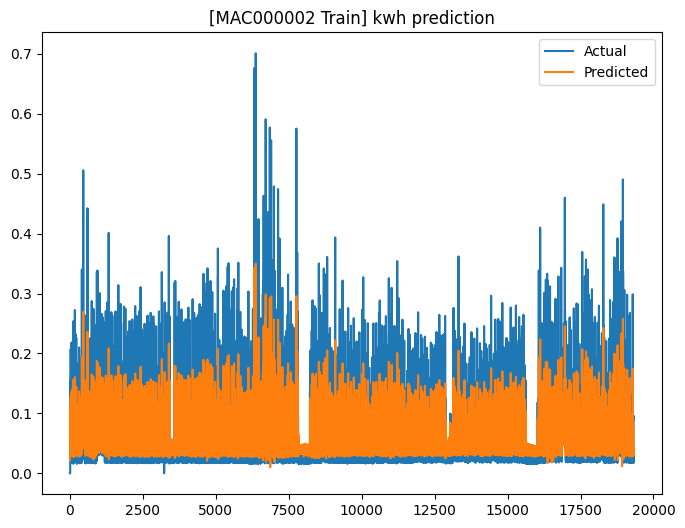

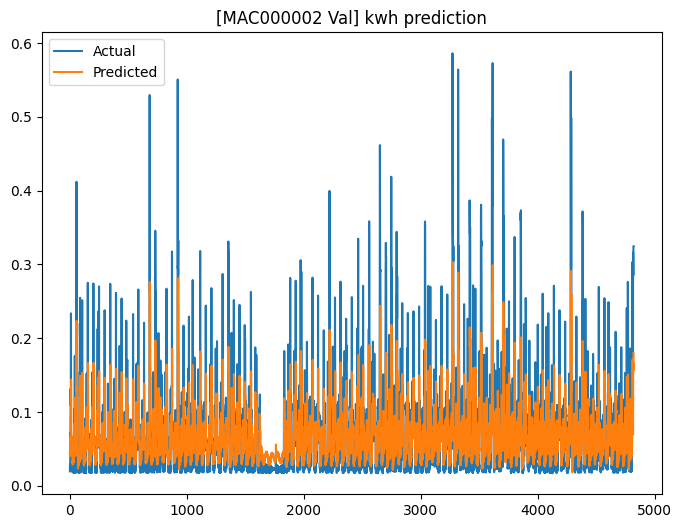

In [ ]:
inference(
    global_model,
    client_X_train, 
    client_y_train,
    client_X_val, 
    client_y_val,
    exogenous_data_train, 
    exogenous_data_val,
    y_scalers,
    apply_round=False  # 对于电力数据（kwh），值通常小于1，不应该四舍五入到整数

)